## Criteria for Resonance Capture and Stability

### <u>Adiabaticity criterion</u>

#### From Lin et al. (2025)

"Relatively slow migration is a necessary resonant capture condition. When the planets undergo fast convergent migration, they directly bypass the resonance before the eccentricities reach their equilibrium values."

For $j$:$j-1$ resonance, the resonance trapping criterion of slow migration for $q \ll 1$ is 
$$\tau_m > \frac{1}{n_1 ( 3(k-1))^{1/3}} \frac{1}{(\mu_2 \alpha f)^{4/3}}$$
where $\mu_i=m_i/M$ and $q=m_1/m_2$. Small $e$'s are assumed.

#### From Batygin & Morbidelli (2026)

In the limit of compact orbits, for $k$:$k-1$ resonance,
$$\frac{1}{\tau_a \Omega_1} \lesssim \frac{5\pi}{8}\left(\frac{5}{36k^5(k-1)^{2/3}}\right)^{1/3} \left(\frac{M}{m_1+m_2}\right)^{4/3}$$

which can be rewritten as

$$\tau_a \Omega_1 \gtrsim \left[ \frac{5\pi}{8}\left(\frac{5}{36k^5(k-1)^{2/3}}\right)^{1/3} \left(\frac{M}{m_1+m_2}\right)^{4/3} \right]^{-1}$$

#### From Batygin (2015)
Additionally, consider Eq. 43 in: [Batygin (2015)](https://arxiv.org/pdf/1505.01778)

### <u>Dissipative stability criterion</u>

#### From Batygin & Morbidelli (2026)

"In resonance, convergence migration excites $e$ while disk tides damp it, and long-lived trapping requires the existence of a fixed point in which these effects balance. As such, the resonant forcing must be sufficiently strong to offset $e$ damping... if $e$ damping is too strong relative to the resonant forcing, no stationary resonant equilibrium exists."

$$\frac{1}{\tau_a \Omega} \lesssim \frac{m_2}{M} \sqrt{\frac{32k^3 (1+\zeta) (\zeta \, \mathcal{K_1} + \mathcal{K_2})}{25\mathcal{K_1}\mathcal{K_2}}}$$
where $\mathcal{K_j} = \tau_a/\tau_{e_j}$. In simulations, $\mathcal{K_1}$ ranged from $10^{0.4}$ to $10^{3.4}$ while they set $\mathcal{K_2} = \mathcal{K_1}/\zeta$.

### <u>Eccentricity criterion</u>

#### From Batygin & Morbidelli (2026)

Orbits must possess sufficiently low eccentricities, which is guaranteed due to $e$ damping in a protoplanetary disk.

### <u>Overstability criterion</u>

#### From Deck & Batygin (2015)
For $m+1\text{:}m$ resonance, the condition for instability is (Eq. 15):
$$\epsilon_p < \epsilon_{p, \rm crit} \equiv \frac{3pm}{\mathcal{B}2^{3/2}} \frac{\tau_e}{\tau_{a,e}} \frac{(1+\zeta)^2}{\left(m(\zeta+1) + p\frac{\tau_e}{\tau_{a,e}}\right)^{3/2}} \left(\frac{\tau_e}{\tau_a}\right)^{3/2}$$

where 
$$\epsilon_p = \frac{m_1+m_2}{M}, \quad \zeta = \frac{m_1}{m_2}, \quad \mathcal{B} \approx 0.8m$$
$$R\equiv \frac{|f|}{g-\delta_{m,2}\alpha_{\rm res}}, \quad \alpha_{\rm res} = \frac{a_1}{a_2} = \left(\frac{k-1}{k}\right)^{2/3}$$
$$\tau_a = \left(\frac{1}{\tau_{a_2}} - \frac{1}{\tau_{a_1}} \right)^{-1}, \quad \tau_e = \left(\frac{1}{\tau_{e_1}} + \frac{\zeta}{\tau_{e_2}} \right)^{-1}, \quad \tau_{a,e} = \left(\frac{1}{\tau_{e_1}} - \frac{\zeta^2 \alpha_{\rm res}}{R^2 \tau_{e_2}} \right)^{-1}$$

See Eq. 15 in [Deck & Batygin (2015)](https://arxiv.org/pdf/1506.01382). Additionally, consider the escape criterion in Eq. 21.

#### From Batygin & Morbidelli (2026)

For low values of $\mathcal{K}$, resonance locking gives way to the onset of overstability of resonant librations. The instability criterion is

$$\left[ \frac{\zeta (k(1+\zeta)-2\zeta)}{1-\zeta} \frac{\chi_a}{\chi_e}\right]^{3/2} < \frac{15}{32} \frac{1-\zeta^2}{M/m_2}\left(\frac{h}{r}\right)^3$$
where $h/r$ is the aspect ratio, $\chi_a = 1/(2.7+1.1s)$, $\chi_e = 1/0.780$. However, there may be a typo here where it should be $m_2/M$ instead of $M/m_2$.

### <u>Damping timescales</u>

#### From Batygin & Morbidelli (2026)
$$\tau_{a_j} = \chi_a \left( \frac{m_j}{M} \frac{\Sigma a_j^2}{M} \left(\frac{h}{r}\right)^{-2} \Omega_j \right)^{-1}$$
$$\tau_{e_j} = \frac{\chi_e}{\chi_a} \left(\frac{h}{r}\right)^{2} \tau_{a_j}$$
where $h/r$ is the aspect ratio, $\chi_a = 1/(2.7+1.1s)$, $\chi_e = 1/0.780$.

### <u>K-Factors</u>
From Batygin & Morbidelli (2026), we have
$\mathcal{K_1} = \tau_a/\tau_{e_1}$ and $\mathcal{K_2} = \tau_a/\tau_{e_2}$. 

### Plotting the above criteria

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
import astropy.units as u
from pathlib import Path
import rebound_sims as reb_sims
from timescales import *
from resonance_criteria import *
from helpers import get_omega

def plot_prettier(dpi=200, fontsize=8, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

/Users/danchen/Documents/reboundx/reboundx/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [31]:
m1 = 1 * m_earth
m2 = 5 * m_earth
m_star = 1
s = 1
x_min, x_max = 0.01, 7.5
y_min, y_max = 0.009, 0.11

0
0
0
1
1
1


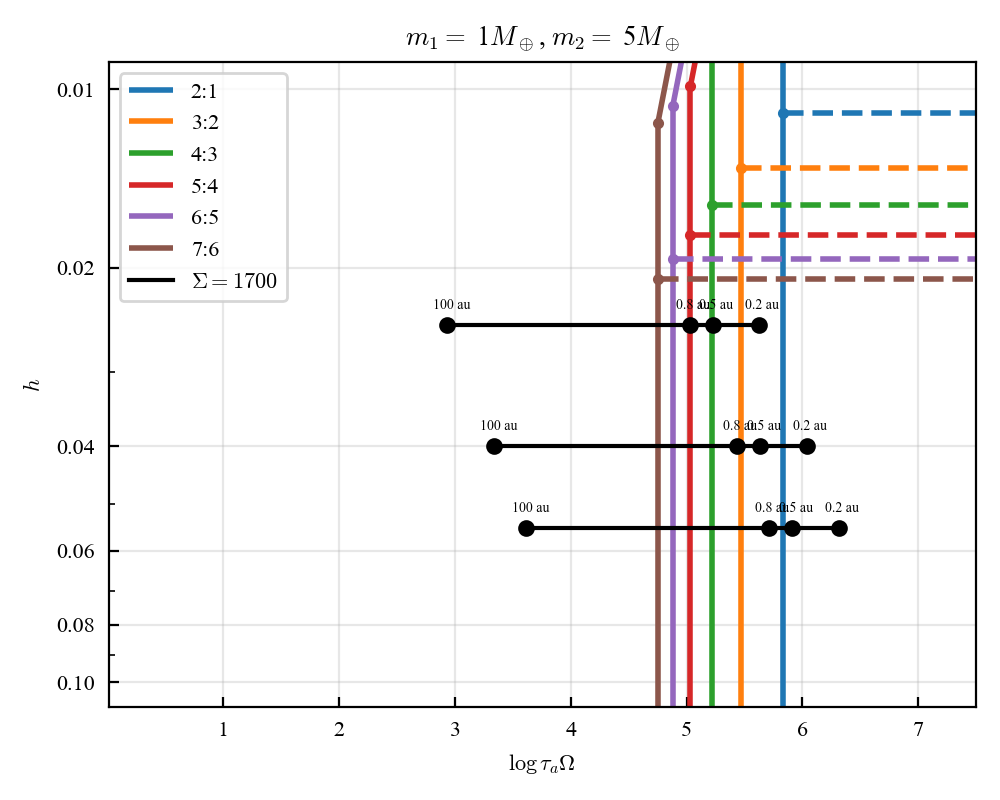

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 

# Criterion boundaries
for k in range(2,8):

    color = colors[k-2]

    # Adiabaticity (vertical), plotted later
    x = np.log10(adiabaticity_crit(k, m_star, m1, m2))

    # Overstability (horizontal) 
    parameters = {
        "Sigma_1au": 100,
        "h_1au": 0.05,
        "alpha": s,
        "beta": 0,
        "ide_position": 0.1,
        "ide_width": 0.05
    }
    
    r1 = (m1/m_earth)**(1/3) * r_earth
    r2 = (m2/m_earth)**(1/3) * r_earth
    a1 = 1
    a2 = a1 * (k/(k-1))**(2/3) # exact resonance
    
    hcrit = h_overstable_boundary(k, parameters, m_star, m1, m2, r1, r2, a1, a2, hmin=y_min, hmax=y_max)
    if np.isfinite(hcrit):
        ax.axhline(hcrit, color=color, lw=2, ls='--', xmin=(x-x_min)/(x_max-x_min))
        ax.plot(x, hcrit, 'o', color=color, ms=3)
        # If nothing shows up, then it's probably overstable for the h range in the function
    # print(hcrit)
    
    # Dissipative stability (diagonal)
    h_scan = np.linspace(y_min, y_max, 500)
    C_scan = np.full_like(h_scan, np.nan)
    for idx, h in enumerate(h_scan):
        val = dissipative_crit(k, m_star, m1, m2, h, s=s)
        if np.isfinite(val) and val > 0:
            C_scan[idx] = np.log10(val ** -1)  # log10, matching the adiabaticity line's convention

    valid = np.isfinite(C_scan)
    h_v, C_v = h_scan[valid], C_scan[valid]
    
    if len(h_v) >= 2:
        above = C_v >= x
        h_branch = list(h_v[above])
        C_branch = list(C_v[above])

        # interpolate the exact crossing point(s) with x = x so the dashed
        # line ends precisely at the adiabaticity boundary
        edges = np.where(np.diff(above.astype(int)) != 0)[0]
        for e in edges:
            h0, h1 = h_v[e], h_v[e + 1]
            C0, C1 = C_v[e], C_v[e + 1]
            if C1 != C0:
                frac = (x - C0) / (C1 - C0)
                h_int = h0 + frac * (h1 - h0)
                h_branch.append(h0 + frac * (h1 - h0))
                C_branch.append(x)
                ax.plot(x, h_int, 'o', color=color, ms=3)

        if len(h_branch) > 0:
            order = np.argsort(h_branch)
            ax.plot(np.array(C_branch)[order], np.array(h_branch)[order],
                    '-', color=color, lw=2)
        
        ax.vlines(x, ymin=h_int if len(edges) != 0 else y_min, ymax=y_max,
              color=color, lw=2, label=rf"{k}:{k-1}")
                
# Add evolution track for a given Sigma0 and h0
def plot_disk_track(ax, Sigma_1au, h_1au, k, m1, m2, a_values=(0.2, 0.5, 0.8, 100), color="k", marker="o", ms=5, lw=1.5, label=None):
    """Plot the location of a disk model in (log10(tau_a Omega1), h) for several semimajor axes."""

    parameters = {
        "Sigma_1au": Sigma_1au,
        "h_1au": h_1au,
        "alpha": s,
        "beta": 0,
        "ide_position": 0.1,
        "ide_width": h_1au
    }
    
    alpha_res = ((k - 1) / k)**(2/3)
    r1 = (m1/m_earth)**(1/3) * r_earth
    r2 = (m2/m_earth)**(1/3) * r_earth

    xs = []
    ys = []

    for a1 in a_values:
        a2 = a1 / alpha_res

        ta1, te1 = get_ta_te(parameters, m_star, m1, r1, a1, t=0, ide=True, tau='mig_and_gas')
        ta2, te2 = get_ta_te(parameters, m_star, m2, r2, a2, t=0, ide=True, tau='mig')

        ta = 1 / (1 / ta2 - 1 / ta1) # Relative migration timescale
        Omega1 = get_omega(m_star, m1, a1)
        tau_a_Omega = ta * Omega1

        xs.append(np.log10(tau_a_Omega))
        ys.append(h_1au)

    ax.plot(xs, ys, "-", color=color, lw=lw, label=label)

    ax.scatter(xs, ys, s=ms**2, color=color, zorder=5)

    # Labels for each point
    for x, y, a in zip(xs, ys, a_values):
        ax.annotate(f"{a:g} au", (x, y), xytext=(-5, 6), textcoords="offset points", fontsize=5, color=color)
        
k = 3
# plot_disk_track(ax, Sigma_1au=500, h_1au=0.06, k=k, m1=m1, m2=m2, color="b", label=r"$\Sigma=500$")
# plot_disk_track(ax, Sigma_1au=500, h_1au=0.045, k=k, m1=m1, m2=m2, color="b")
# plot_disk_track(ax, Sigma_1au=500, h_1au=0.03, k=k, m1=m1, m2=m2, color="b")

plot_disk_track(ax, Sigma_1au=1700, h_1au=0.055, k=k, m1=m1, m2=m2, color="k", label=r"$\Sigma=1700$")
plot_disk_track(ax, Sigma_1au=1700, h_1au=0.04, k=k, m1=m1, m2=m2, color="k")
plot_disk_track(ax, Sigma_1au=1700, h_1au=0.025, k=k, m1=m1, m2=m2, color="k")

# plot_disk_track(ax, Sigma_1au=5000, h_1au=0.05, k=k, m1=m1, m2=m2, color="r", label=r"$\Sigma=5000$")
# plot_disk_track(ax, Sigma_1au=5000, h_1au=0.035, k=k, m1=m1, m2=m2, color="r")
# plot_disk_track(ax, Sigma_1au=5000, h_1au=0.02, k=k, m1=m1, m2=m2, color="r")

ax.set_xlabel(r"$\log \tau_a \Omega$")
ax.set_ylabel(r"$h$")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_yscale("log")
ax.set_yticks([0.01,0.02,0.04,0.06,0.08,0.10])
ax.set_yticklabels(['0.01','0.02','0.04','0.06','0.08','0.10'])
ax.yaxis.set_inverted(True)
ax.set_title(rf"$m_1 =$ {m1/m_earth:.2g}$M_\oplus$, $m_2 =$ {m2/m_earth:.2g}$M_\oplus$")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

%matplotlib widget

### Plotting $\delta$ vs $e_r$

Leleu et al. (2026) gives

$$\delta = \frac{2}{3} \left(\frac{C_\delta f_{\rm super}}{M^{2/3}}+R\right) - 1$$

$$C_\delta = \left(\frac{3p^{1/2}}{|f_1|}\right)^{2/3}$$

Replacing $R$ by $e_r^2/2$, we obtain $$\Delta_R = \frac{1}{2} (3(\delta + 1) - e_r^2) C_\delta^{2/3} M^{2/3}$$

Additionally, 

$$\Delta_{\rm MMR} = e_r^2 - 3(\delta + 1) = K_p M^{-2/3} \left[\left( \frac{P_2}{P_1}\frac{p}{p+1}\right)^{1/3}-1\right]$$

$$f_{\rm super} = 2\pi \left(\frac{p}{P_1} - \frac{p+1}{P_2} \right)$$

$$M \approx M_C = \left(\frac{m_1 + \left(\frac{p}{p+1}\right)^{2/3} m_2}{m_\star}\right)$$
for $p+1$:$p$ MMR.

In [4]:
def compute_R(a1,a2,e1,e2,pomega1,pomega2,m1,m2,m_star,f1,f2,G=1):
    Lambda1 = m1*np.sqrt(G*m_star*a1)
    Lambda2 = m2*np.sqrt(G*m_star*a2)

    # check normalization against Leleu appendix
    Kr = Lambda1*Lambda2/(Lambda1+Lambda2)

    R = Kr * (
        f1**2*e1**2
        + f2**2*e2**2
        + 2*f1*f2*e1*e2*np.cos(pomega1-pomega2)
    )

    return R

def compute_delta_er(P1,P2,a1,a2,e1,e2,pomega1,pomega2,m1,m2,m_star,p,f1,f2,G=1):

    # super-frequency
    fsuper = 2*np.pi*(p/P1-(p+1)/P2)

    # mass parameter
    M = (m1+(p/(p+1))**(2/3)*m2)/m_star

    # resonant coefficient
    Cdelta = (3*np.sqrt(p)/abs(f1))**(2/3)

    R = compute_R(a1,a2,e1,e2,pomega1,pomega2,m1,m2,m_star,f1,f2,G)
    Rmax = R.max()
    
    er = np.sqrt(2*Rmax)    
    delta = 2/3*(Cdelta*fsuper/M**(2/3)+R) - 1

    return delta, er

with open("fg_library.pkl", "rb") as f:
    fg_lib = pkl.load(f)

p = 3 # for p+1:p resonance
# From Table B1
f1 = [1.1904936978, 2.0252226899, 2.8404318567, 3.6496182441, 4.4561427851][p-1]
f2 = -[0.4283898341, 2.4840051833, 3.2832567218, 4.0837053718, 4.8847062975][p-1]

dataset_id = 7
sim_id = 155
base_dir = Path.cwd()
file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
saved_sim = reb_sims.load_simulation_run(file_path)

sim_data, metadata = saved_sim

m1, m2, m_star = metadata['m_vals'][0], metadata['m_vals'][1], metadata['m_star']
P1, P2 = sim_data['planet b']['P'].iloc[-1], sim_data['planet c']['P'].iloc[-1]
a1, a2 = sim_data['planet b']['a'].iloc[-1], sim_data['planet c']['a'].iloc[-1]
e1, e2 = sim_data['planet b']['e'].iloc[-1], sim_data['planet c']['e'].iloc[-1]
pomega1, pomega2 = sim_data['planet b']['pomega'].iloc[-1], sim_data['planet c']['pomega'].iloc[-1]

delta, er = compute_delta_er(P1,P2,a1,a2,e1,e2,pomega1,pomega2,m1,m2,m_star,p,f1,f2)
print(f"δ = {delta:.4g}, e_r = {er:.4g}")

δ = 377.4, e_r = 0.0003003


In [5]:
p = 3 # for p+1:p resonance
f1, f2 = fg_lib[(p+1, p)]
print(-f1, f2)

0.7930604745729224 1.077995691783619
